# Retrieval Augmented Generation - RAG / Generación Potenciada por Recuperación
### ChromaDB Vector Embeddings con LangChain
Ref> https://airbyte.com/data-engineering-resources/chroma-db-vector-embeddings

RAG (Retrieval-Augmented Generation) es una técnica que combina la recuperación de información con la generación de texto mediante modelos de lenguaje. En lugar de depender únicamente del conocimiento que un modelo aprendió durante su entrenamiento, un sistema RAG primero busca (recupera) fragmentos relevantes de una fuente externa de datos —como documentos, PDFs o bases de datos vectoriales— y luego usa esa información como contexto para que el modelo genere una respuesta más precisa, actualizada y fundamentada en esas fuentes, reduciendo así el riesgo de "alucinaciones" o respuestas inventadas.

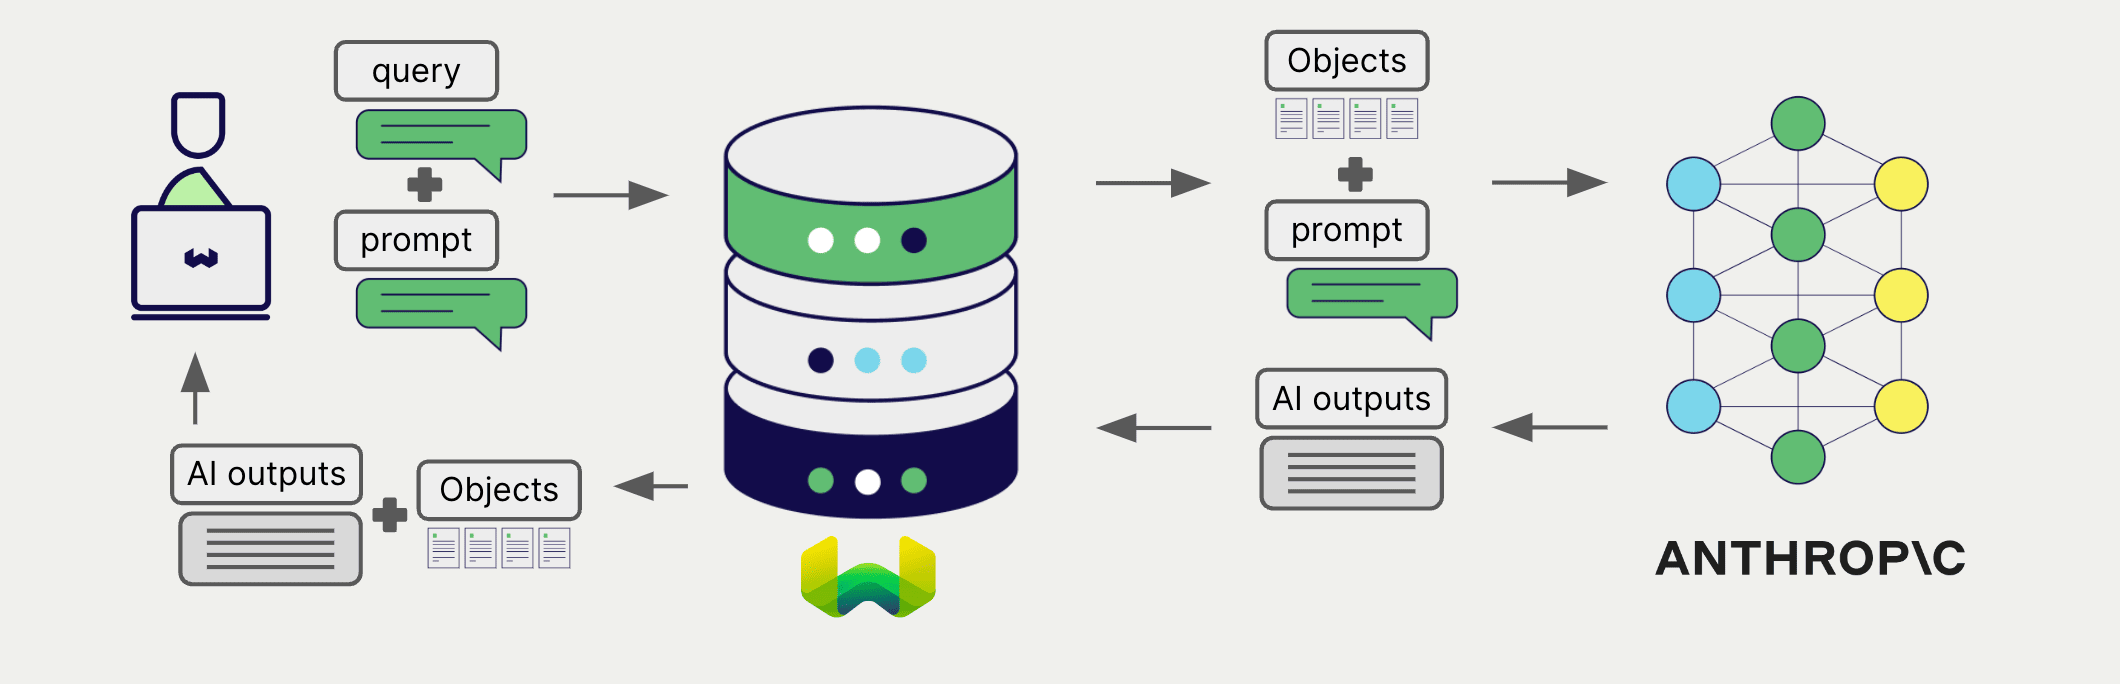

In [ ]:
%pip install -qU langchain-community pypdf langchain_chroma

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from langchain_community.document_loaders import PyPDFLoader

file_path = "./data/openaiguide.pdf"
loader = PyPDFLoader(file_path)

Este código usa LangChain para cargar un archivo PDF y dividirlo en documentos, uno por página. Importa el módulo pprint ("pretty print"), que sirve para imprimir estructuras de datos (como diccionarios) de forma más legible y ordenada que con un print() normal.

In [9]:
file_path = "./data/openaiguide.pdf"

Define la ruta relativa al archivo PDF que se va a cargar. Luego, carga un PDF llamado openaiguide.pdf, lo divide en una lista de documentos (uno por página), muestra cuántas páginas tiene, y muestra los metadatos asociados a la primera página. Es un patrón típico al preparar documentos para sistemas de RAG (Retrieval-Augmented Generation), donde luego normalmente se trocearía (chunking) y se indexaría el texto en una base de datos vectorial.

In [13]:
import pprint


loader = PyPDFLoader(
    file_path,
    mode="page",  ## Cargar por página, tambien puede ser entero usando "single"
)
docs = loader.load()
print(len(docs))

pprint.pp(docs[0].metadata)

34
{'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)',
 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)',
 'creationdate': '2025-04-07T14:20:51+00:00',
 'moddate': '2025-04-07T14:20:54+00:00',
 'source': './data/openaiguide.pdf',
 'total_pages': 34,
 'page': 0,
 'page_label': '1'}


#### chunking (fragmentación) de los documentos cargados del PDF
 Un paso esencial en RAG para dividir textos largos en fragmentos más pequeños que puedan procesarse e indexarse eficientemente. Se muestran dos enfoques: primero, un chunking básico con CharacterTextSplitter, que divide el texto en fragmentos de 1000 caracteres sin solapamiento (chunk_overlap=0), es decir, cada chunk es completamente independiente y no comparte contenido con el anterior ni el siguiente, lo que puede provocar pérdida de contexto en los bordes. Segundo, un chunking más avanzado con RecursiveCharacterTextSplitter, que también genera fragmentos de 1000 caracteres pero con un solapamiento de 200 caracteres (chunk_overlap=200) entre chunks consecutivos, preservando parte del contexto entre ellos para mejorar la coherencia semántica. Además, este splitter usa una lista jerárquica de separadores (["\n\n", "\n", " ", ""]), intentando dividir primero por párrafos dobles, luego por saltos de línea simples, luego por espacios, y como último recurso por caracteres individuales, lo que produce cortes más naturales y respetuosos con la estructura del texto original en comparación con un corte puramente mecánico por número de caracteres.

In [15]:
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter

# Chunking Básico sin solapamiento
text_splitter = CharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=0
)
documents = text_splitter.split_documents(docs)

# Chunking Semántico con solapamiento
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,  # Mantenemos contexto entre chunks
    separators=["\n\n", "\n", " ", ""] # Definimos separadores jerárquicos
)
documents = text_splitter.split_documents(docs)

In [ ]:
import re

def validar_dni(dni: str) -> bool:
    patron = r"^\d{8}$"
    return bool(re.fullmatch(patron, dni))

for doc in documents[:3]:  # Mostramos los primeros 3 chunks
    print(doc.page_content)
    print("Metadata:", doc.metadata)
    print("-" * 80)
    if validar_dni(doc.page_content.strip()):
        print(f"DNI válido encontrado: {doc.metadata['source']}")


A practical  
guide to  
building agents
Metadata: {'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': '2025-04-07T14:20:51+00:00', 'moddate': '2025-04-07T14:20:54+00:00', 'source': './data/openaiguide.pdf', 'total_pages': 34, 'page': 0, 'page_label': '1'}
--------------------------------------------------------------------------------
Contents
What is an agent? 4
When should you build an agent? 5
Agent design foundations 7
Guardrails 24
Conclusion 32
2 Practical guide to building agents
Metadata: {'producer': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creator': 'pdf-lib (https://github.com/Hopding/pdf-lib)', 'creationdate': '2025-04-07T14:20:51+00:00', 'moddate': '2025-04-07T14:20:54+00:00', 'source': './data/openaiguide.pdf', 'total_pages': 34, 'page': 1, 'page_label': '2'}
--------------------------------------------------------------------------------
Introduction
Large language models are bec

Embed text and store in ChromaDB

In [16]:
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma

db = Chroma.from_documents(documents, OpenAIEmbeddings())

Similarity search

In [ ]:
query = "workflow definition"
docs = db.similarity_search(query)
print(docs[0].page_content)

A s y ou e v alua t e wher e agen ts can add v alue ,  prioritiz e w orkflo w s tha t ha v e pr e viously  r esist ed 
aut oma tion,  especially  wher e tr aditional me thods encoun t er  fric tion:
01 C o m p l e x   
d e c i s i o n - m a k i n g :  
W orkflo w s in v olving nuanced judgmen t,  e x cep tions,  or   
con t e xt -sensitiv e decisions,  f or  e x ample r e fund appr o v al  
in cust omer  service w orkflo w s.
02 D i ffi c u l t - t o - m a i n t a i n  
r u l e s :
S y st ems tha t ha v e become unwieldy  due t o e xt ensiv e and 
in trica t e rulese ts,  making upda t es costly  or  err or -pr one ,   
f or  e x ample perf orming v endor  security  r e vie w s.  
03 H e a v y  r e l i a n c e  o n  
u n s t r u c t u r e d  d a t a :
Scenarios tha t in v olv e in t erpr e ting na tur al language ,   
e xtr ac ting meaning fr om documen ts,  or  in t er ac ting with  
user s con v er sa tionally ,  f or  e x ample pr ocessing a home 
insur ance claim.


Advanced RAG Implementation


In [18]:
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter

# Chunking Básico sin solapamiento
text_splitter = CharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=0
)
documents = text_splitter.split_documents(docs)

# Chunking Semántico con solapamiento
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", " ", ""]
)
documents = text_splitter.split_documents(docs)

#### Ahora probemos con una web

In [ ]:
# Load docs
from langchain_community.document_loaders import WebBaseLoader
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma

loader = WebBaseLoader("https://github.com/chiphuyen/aie-book/blob/main/chapter-summaries.md")
data = loader.load()

# Split
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=0)
all_splits = text_splitter.split_documents(data)

# Store splits
vectorstore = Chroma.from_documents(documents=all_splits, embedding=OpenAIEmbeddings())

# LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.2)



In [22]:
from langchain.agents import create_agent
from langchain.tools import tool

# Convertimos el vectorstore en una tool que el agente puede invocar
@tool
def retrieve_context(query: str) -> str:
    """Busca y devuelve fragmentos relevantes del documento sobre RAG (Chip Huyen) para responder la pregunta del usuario."""
    docs = vectorstore.as_retriever().invoke(query)
    return "\n\n".join(doc.page_content for doc in docs)


agent = create_agent(
    model=llm,  # el ChatOpenAI que ya definiste
    tools=[retrieve_context],
    debug=True,
    system_prompt=(
        "Eres un asistente de preguntas y respuestas. Usa la herramienta "
        "retrieve_context para buscar información relevante antes de responder. "
        "Si no encuentras la respuesta en el contexto recuperado, dilo claramente."
    ),
)

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Define RAG en 3 bullets como si fueras Chip Huyen, con referencias a los documentos usados.",
            }
        ]
    }
)

print(result["messages"][-1].content)

[values] {'messages': [HumanMessage(content='Define RAG en 3 bullets como si fueras Chip Huyen, con referencias a los documentos usados.', additional_kwargs={}, response_metadata={}, id='1e44e28b-6b33-43ff-b16a-d85e737c6617')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 120, 'total_tokens': 135, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_6cc92eaef9', 'id': 'chatcmpl-E5Mbjmg8Ad7Qu3OY7GYMgVuxUFYCp', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f9725-91a0-79f1-9a10-386791ff37a1-0', tool_calls=[{'name': 'retrieve_context', 'args': {'query'